# Day 8: Business Scenario & Aggregation

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/sales_cleaned.csv')
df.head()

,Date,Product,Region,Quantity,Sales
0,2024-01-01,Monitor,North,2,754.98
1,2024-01-03,Monitor,East,4,1732.20
2,2024-01-03,Mouse,West,1,53.61
3,2024-01-07,Headphones,East,8,1566.60
4,2024-01-08,Headphones,West,8,1628.57


## Section 1: Multi-Level Aggregation

In [2]:
summary = df.groupby(['Product', 'Date']).agg({
    'Sales': ['sum', 'count'],
    'Quantity': 'mean'
})

summary.columns = ['Total_Revenue', 'Transaction_Count', 'Avg_Qty_Per_Order']

print("Executive Deep-Dive:")
print(summary.head(10))

Executive Deep-Dive:
                       Total_Revenue  Transaction_Count  Avg_Qty_Per_Order
Product    Date                                                           
Headphones 2024-01-07        1566.60                  1                8.0
           2024-01-08        1628.57                  1                8.0
           2024-01-12         879.57                  1                4.0
           2024-01-18         834.56                  1                4.0
           2024-01-19         832.73                  1                4.0
           2024-01-22        1696.82                  2                4.0
           2024-01-24        1971.37                  1               10.0
           2024-01-25        1106.77                  1                6.0
Keyboard   2024-01-12         565.14                  1                6.0
           2024-01-17         214.82                  1                2.0


## Section 2: Scenario Analysis

In [3]:
df['Projected_Rev_High_Price'] = df['Sales'] * 1.15

low_perf_threshold = df['Sales'].quantile(0.25)
underperforming_data = df[df['Sales'] < low_perf_threshold]

print(f"Number of low-performing transactions: {len(underperforming_data)}")

Number of low-performing transactions: 8


## Section 3: Top-N Analysis

In [4]:
top_performers = df.groupby('Product')['Sales'].sum().nlargest(5)

total_rev = df['Sales'].sum()
contribution_pct = (top_performers.sum() / total_rev) * 100

print(f"Top 5 Products contribute {contribution_pct:.2f}% of total revenue.")

Top 5 Products contribute 100.00% of total revenue.


## Section 4: Filter & Visualize — Cumulative Sales

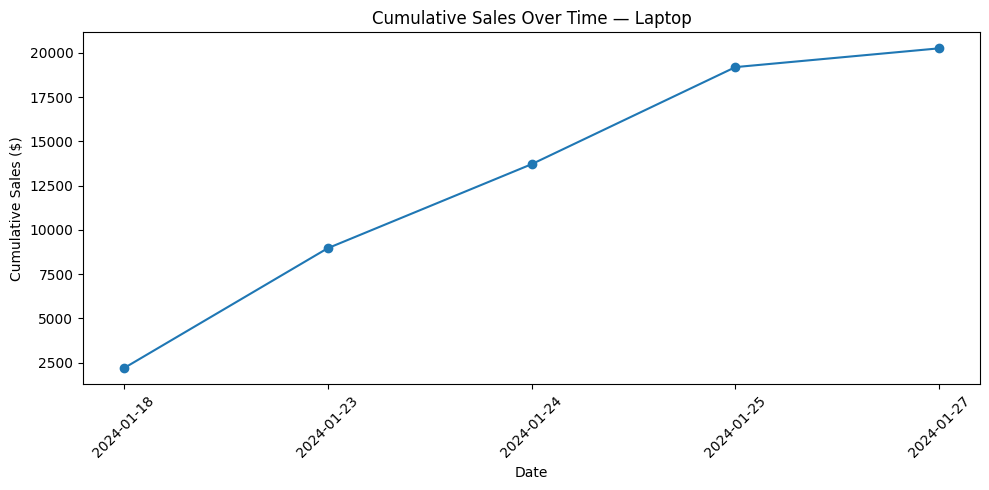

In [5]:
product_df = df[df['Product'] == 'Laptop'].copy()
product_df = product_df.sort_values('Date')
product_df['Cumulative_Sales'] = product_df['Sales'].cumsum()

plt.figure(figsize=(10, 5))
plt.plot(product_df['Date'], product_df['Cumulative_Sales'], marker='o')
plt.title('Cumulative Sales Over Time — Laptop')
plt.xlabel('Date')
plt.ylabel('Cumulative Sales ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../data/cumulative_sales.png', dpi=150)
plt.show()

## Reflection

**Why is it important for an analyst to look at 'Transaction Count' alongside 'Total Revenue'? Can a high revenue number ever be misleading?**

Yes — a high revenue number can be misleading. If one product shows $50,000 in revenue from only 5 transactions, it looks strong but is actually fragile — losing one customer wipes out 20% of revenue. Meanwhile another product with $48,000 from 400 transactions has a far more stable, diversified customer base.

Transaction count reveals demand frequency and customer concentration risk. Revenue alone shows size; transaction count shows the health and reliability of that revenue.